Ноутбук `exp02_fine_tuning_params.ipynb` предназначен для тестирования разных параметров обучения, используемых в обучении основной модели `DeepPavlov/rubert-base-cased-conversational`. 

Параметры можно изменять в файле конфигурации .yaml, а именно в `exp02_config.yaml`, который лежит в папке configs/.

Артефакты эксперементов из этого ноутбука сохраняются в `artifacts/bert_finetuning_test`.

In [14]:
import random 
from typing import Iterable, Dict, List
from pathlib import Path
import matplotlib.pyplot as plt
import yaml

RANDOM_STATE = 42
from datasets import Dataset, DatasetDict
import numpy as np 
import pandas as pd 
import torch 
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding, Trainer, TrainingArguments, AutoModelForSequenceClassification


BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BACKEND_DIR = BASE_DIR.parent
elif BASE_DIR.name == "backend":
    BACKEND_DIR = BASE_DIR
else:
    BACKEND_DIR = BASE_DIR / "backend"

DIRECTORIES_CONFIG_PATH = BACKEND_DIR / "configs" / "directories.yaml"

with DIRECTORIES_CONFIG_PATH.open("r", encoding="utf-8") as file:
    directories_config = yaml.safe_load(file)

def configured_path(name: str) -> Path:
    return (BACKEND_DIR / directories_config["paths"][name]).resolve()

DATASET_PATH = configured_path("dataset")
ARTIFACTS_DIR = configured_path("artifacts_dir")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

with open(BACKEND_DIR / "configs" / "exp02_config.yaml", "r", encoding="utf-8") as file:
    exp02_config = yaml.safe_load(file)

MODEL_NAME = exp02_config["model"]["name"]
MAX_LENGTH = exp02_config["model"]["max_length"]
RANDOM_STATE = exp02_config["random_state"]
split_config = exp02_config["split"]
training_config = exp02_config["training"]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


In [15]:
df = pd.read_csv(DATASET_PATH, sep=";")


df.head()

,ID,text,label
0,1,"Регулярный платёж списался частично, остаток в...",PAYMENT_OUT_FAIL
1,2,задержка по кэшбэку уже 9 рабочих дней когда н...,INCOMING_DELAY
2,3,Face ID крутится и возвращает на экран логина....,APP_LOGIN
3,4,аналитика расходов крутится бесконечно данных ...,APP_TECH
4,5,звонили представились банком просили код ничег...,FRAUD_SUSPECTED


In [16]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer class: {tokenizer.__class__.__name__}')
print(f'Tokenizer max length: {tokenizer.model_max_length}')

Tokenizer class: BertTokenizer
Tokenizer max length: 1000000000000000019884624838656


In [17]:

label_names = df['label'].unique()
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df['label_id'] = df['label'].map(label2id)

train_df, test_df = train_test_split(
    df, 
    test_size=split_config["test_size"], 
    random_state=RANDOM_STATE, 
    stratify=df['label_id'],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=split_config["validation_size"], 
    random_state=RANDOM_STATE, 
    stratify=train_df['label_id'],
)


train_ds = Dataset.from_pandas(
    train_df[['text', 'label_id']].rename(columns={'label_id': 'labels'}).reset_index(drop=True),
    preserve_index=False,
)

val_ds = Dataset.from_pandas(
    val_df[['text', 'label_id']].rename(columns={'label_id': 'labels'}).reset_index(drop=True),
    preserve_index=False, 
)

test_ds = Dataset.from_pandas(
    test_df[['text', 'label_id']].rename(columns={'label_id': 'labels'}).reset_index(drop=True),
    preserve_index=False, 
)

dataset_dict = DatasetDict({
    "train": train_ds, 
    "validation": val_ds, 
    "test": test_ds, 
})


def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch['text'],
        truncation=True, 
        max_length=MAX_LENGTH, 
    )
    
    
tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets['train'][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")
    
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)


Map: 100%|██████████| 250/250 [00:00<00:00, 42713.59 examples/s]

labels: shape=(3,)
input_ids: shape=(3, 12)
token_type_ids: shape=(3, 12)
attention_mask: shape=(3, 12)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 38013.69it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from 

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weghted = f1_score(labels, preds, average='weighted')
    
    return {
        'accuracy': acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weghted
    }
    

EXPERIMENT_DIR = configured_path("exp02_dir")
CHECKPOINTS_DIR = configured_path("exp02_checkpoints_dir")
TEST_MODEL_DIR = configured_path("exp02_test_model_dir")

CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
TEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

common_training_params = dict(
    output_dir=str(CHECKPOINTS_DIR),
    learning_rate=float(training_config["learning_rate"]), 
    per_device_train_batch_size=training_config["train_batch_size"],
    per_device_eval_batch_size=training_config["eval_batch_size"], 
    gradient_accumulation_steps=training_config["gradient_accumulation_steps"],
    num_train_epochs=training_config["epochs"], 
    weight_decay=0.01, 
    logging_steps=training_config["logging_steps"], 
    save_total_limit=1, 
    load_best_model_at_end=True, 
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
    use_cpu=training_config["use_cpu"],
)

In [19]:
try:
    training_args = TrainingArguments(
        evaluation_strategy='epoch',
        save_strategy="epoch",
        **common_training_params,
    )
except TypeError: 
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_params,
    )

try: 
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer, 
        data_collator=data_collator,
        compute_metrics=compute_metrics, 
    )
except TypeError:
    trainer=Trainer(
        model=model, 
        args=training_args,
        train_dataset=tokenized_datasets['train'],
        eval_dataset=tokenized_datasets['validation'],
        tokenizer=tokenizer, 
        data_collator=data_collator, 
        compute_metrics=compute_metrics,
    )
    
train_results = trainer.train()
print(train_results)

trainer.save_model(TEST_MODEL_DIR)
tokenizer.save_pretrained(TEST_MODEL_DIR)

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

print("\nTest metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,11.940338,1.325386,0.771277,0.759111,0.764247


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SafetensorError: Error while serializing: I/O error: No space left on device (os error 28)

        loss   grad_norm  learning_rate     epoch  step  eval_loss  \
0  16.745665   58.023746       0.000028  0.142349    10        NaN   
1  16.092535   47.272133       0.000026  0.284698    20        NaN   
2  16.149258   60.540028       0.000024  0.427046    30        NaN   
3  14.851906   68.658867       0.000022  0.569395    40        NaN   
4  14.292746   84.197174       0.000020  0.711744    50        NaN   
5  13.160995  104.609543       0.000018  0.854093    60        NaN   
6  12.429088   74.576180       0.000015  0.996441    70        NaN   
7        NaN         NaN            NaN  1.000000    71   1.427482   
8   9.979639   76.806610       0.000013  1.128114    80        NaN   
9   9.822649   78.848480       0.000011  1.270463    90        NaN   

   eval_accuracy  eval_f1_macro  eval_f1_weighted  eval_runtime  \
0            NaN            NaN               NaN           NaN   
1            NaN            NaN               NaN           NaN   
2            NaN            

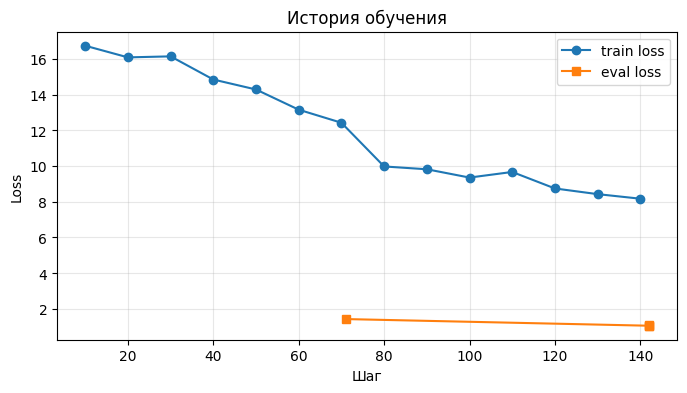

In [ ]:
figures_dir = configured_path("figures_dir")
figures_dir.mkdir(parents=True, exist_ok=True)

history_df = pd.DataFrame(trainer.state.log_history)
print(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(figures_dir / "train_loss_eval_loss_2.png", dpi=300, bbox_inches="tight")